In [1]:
%matplotlib inline

In [2]:
import pandas as pd

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
from statsmodels.tsa.stattools import adfuller

In [7]:
from statsmodels.tsa.arima.model import ARIMA

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [11]:
import warnings

In [12]:
warnings.filterwarnings('ignore')

In [13]:
print("✅ All libraries imported!")

✅ All libraries imported!


In [14]:
df = pd.read_csv('hotel_bookings.csv')

In [15]:
print(f"Shape: {df.shape}")

Shape: (119390, 32)


In [16]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [17]:
print("Missing Values:")

Missing Values:


In [18]:
print(df.isnull().sum()[df.isnull().sum() > 0])

children         4
country        488
agent        16340
company     112593
dtype: int64


In [19]:
df['children'].fillna(0, inplace=True)

In [20]:
df['country'].fillna('Unknown', inplace=True)

In [21]:
df['agent'].fillna(0, inplace=True)

In [22]:
df['company'].fillna(0, inplace=True)

In [23]:
print("✅ Missing values fixed!")

✅ Missing values fixed!


In [24]:
print(df.isnull().sum().sum(), "missing values remaining")

0 missing values remaining


In [25]:
df_clean = df[df['is_canceled'] == 0].copy()

In [26]:
print(f"Original rows    : {len(df):,}")

Original rows    : 119,390


In [27]:
print(f"Confirmed rows   : {len(df_clean):,}")

Confirmed rows   : 75,166


In [28]:
print(f"Cancelled removed: {len(df) - len(df_clean):,}")

Cancelled removed: 44,224


In [29]:
print(df['is_canceled'].value_counts())

is_canceled
0    75166
1    44224
Name: count, dtype: int64


In [30]:
df_clean = df_clean[df_clean['adr'] > 0]

In [31]:
print(f"After removing invalid ADR: {len(df_clean):,}")

After removing invalid ADR: 73,419


In [32]:
df_clean['children'] = df_clean['children'] + df_clean['babies']

In [33]:
df_clean.drop(columns=['babies'], inplace=True)

In [34]:
print("✅ babies merged into children")

✅ babies merged into children


In [35]:
df_clean = df_clean[(df_clean['adults'] + df_clean['children']) > 0]

In [36]:
print(f"After removing zero guests: {len(df_clean):,}")

After removing zero guests: 73,388


In [37]:
print(f"Shape: {df_clean.shape}")

Shape: (73388, 31)


In [38]:
print(f"\nColumns ({len(df_clean.columns)}):")


Columns (31):


In [39]:
print(df_clean.columns.tolist())

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [40]:
df_clean.drop(columns=[
    'is_canceled',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'assigned_room_type',
    'booking_changes',
    'days_in_waiting_list',
    'company',
    'agent',
    'reservation_status',
    'reservation_status_date',
], inplace=True)

In [41]:
print("✅ Useless columns dropped!")

✅ Useless columns dropped!


In [42]:
print(f"Shape: {df_clean.shape}")

Shape: (73388, 21)


In [43]:
print(f"\nRemaining columns:")


Remaining columns:


In [44]:
print(df_clean.columns.tolist())

['hotel', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'reserved_room_type', 'deposit_type', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


In [45]:
df_clean['arrival_date'] = pd.to_datetime(
    df_clean['arrival_date_year'].astype(str) + '-' +
    df_clean['arrival_date_month'].astype(str) + '-01'
)

In [46]:
df_clean.drop(columns=['arrival_date_year', 'arrival_date_month'], inplace=True)

In [47]:
print("✅ Done!")

✅ Done!


In [48]:
print(f"Shape: {df_clean.shape}")

Shape: (73388, 20)


In [49]:
df_clean[['arrival_date']].head()

,arrival_date
2,2015-07-01
3,2015-07-01
4,2015-07-01
5,2015-07-01
6,2015-07-01


In [50]:
print("Date range:", df_clean['arrival_date'].min(), "to", df_clean['arrival_date'].max())

Date range: 2015-07-01 00:00:00 to 2017-08-01 00:00:00


In [51]:
print("Data type:", df_clean['arrival_date'].dtype)

Data type: datetime64[ns]


In [52]:
print("✅ FINAL CLEAN DATASET")

✅ FINAL CLEAN DATASET


In [53]:
print(f"Shape: {df_clean.shape}")

Shape: (73388, 20)


In [54]:
print(f"\nColumns:")


Columns:


In [55]:
print(df_clean.columns.tolist())

['hotel', 'lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'reserved_room_type', 'deposit_type', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'arrival_date']


In [56]:
print(f"\nDate range: {df_clean['arrival_date'].min()} to {df_clean['arrival_date'].max()}")


Date range: 2015-07-01 00:00:00 to 2017-08-01 00:00:00


In [57]:
print(f"\nMissing values: {df_clean.isnull().sum().sum()}")


Missing values: 0


In [58]:
%matplotlib inline

In [59]:
hotel_counts = df_clean['hotel'].value_counts()

In [60]:
print(hotel_counts)

hotel
City Hotel      45119
Resort Hotel    28269
Name: count, dtype: int64


In [61]:
import matplotlib

In [62]:
matplotlib.use('Agg')

In [63]:
import matplotlib.pyplot as plt

In [64]:
plt.style.use('ggplot')

In [65]:
print("Matplotlib backend fixed!")

Matplotlib backend fixed!


In [66]:
fig, ax = plt.subplots(figsize=(7,4))

In [67]:
df_clean['hotel'].value_counts().plot(kind='bar', color=['steelblue','coral'], edgecolor='black', ax=ax)

<Axes: xlabel='hotel'>

In [68]:
ax.set_title('Bookings by Hotel Type')

Text(0.5, 1.0, 'Bookings by Hotel Type')

In [69]:
ax.set_xlabel('Hotel Type')

Text(0.5, -56.902777777777786, 'Hotel Type')

In [70]:
ax.set_ylabel('Number of Bookings')

Text(27.847222222222214, 0.5, 'Number of Bookings')

In [71]:
plt.xticks(rotation=0)

(array([0, 1]), [Text(0, 0, 'City Hotel'), Text(1, 0, 'Resort Hotel')])

In [72]:
plt.tight_layout()

In [73]:
plt.savefig('plot_hotel_type.png', dpi=150)

In [74]:
plt.close()

In [75]:
from IPython.display import Image

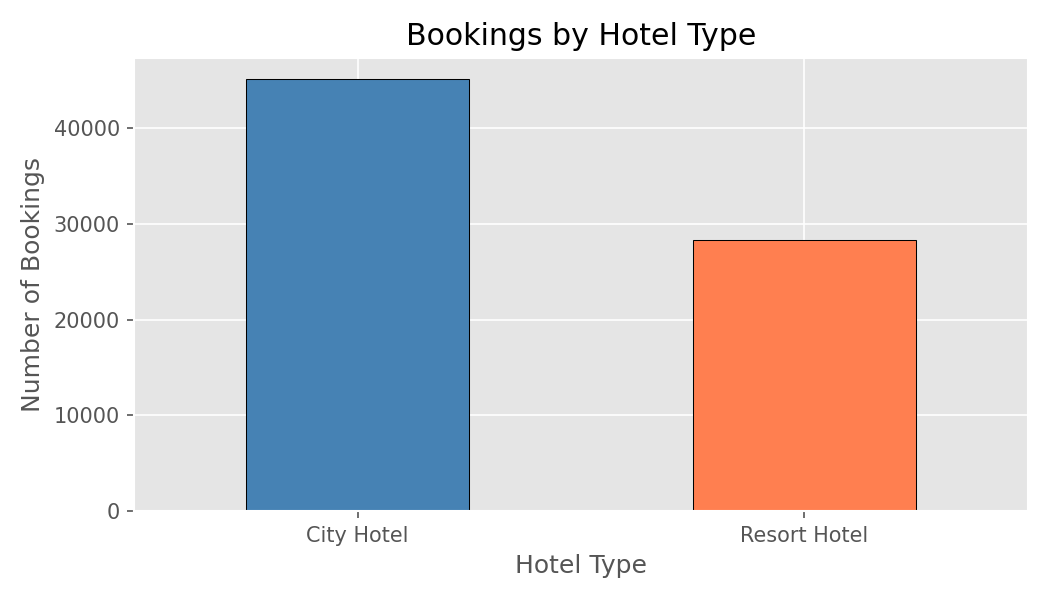

In [76]:
Image('plot_hotel_type.png')

In [77]:
monthly = df_clean.groupby('arrival_date').size().reset_index(name='bookings')

In [78]:
monthly = monthly.sort_values('arrival_date').set_index('arrival_date')


In [79]:
fig, ax = plt.subplots(figsize=(12,5))

In [80]:
ax.plot(monthly.index, monthly['bookings'], marker='o', color='steelblue', linewidth=2)

In [81]:
ax.set_title('Monthly Hotel Bookings (2015-2017)')

Text(0.5, 1.0, 'Monthly Hotel Bookings (2015-2017)')

In [82]:
ax.set_xlabel('Month')

Text(0.5, 25.722222222222214, 'Month')

In [83]:
ax.set_ylabel('Bookings')

Text(99.22222222222221, 0.5, 'Bookings')

In [84]:
plt.tight_layout()

In [85]:
plt.savefig('plot_monthly_trend.png', dpi=150)

In [86]:
plt.close()

In [87]:
from IPython.display import Image

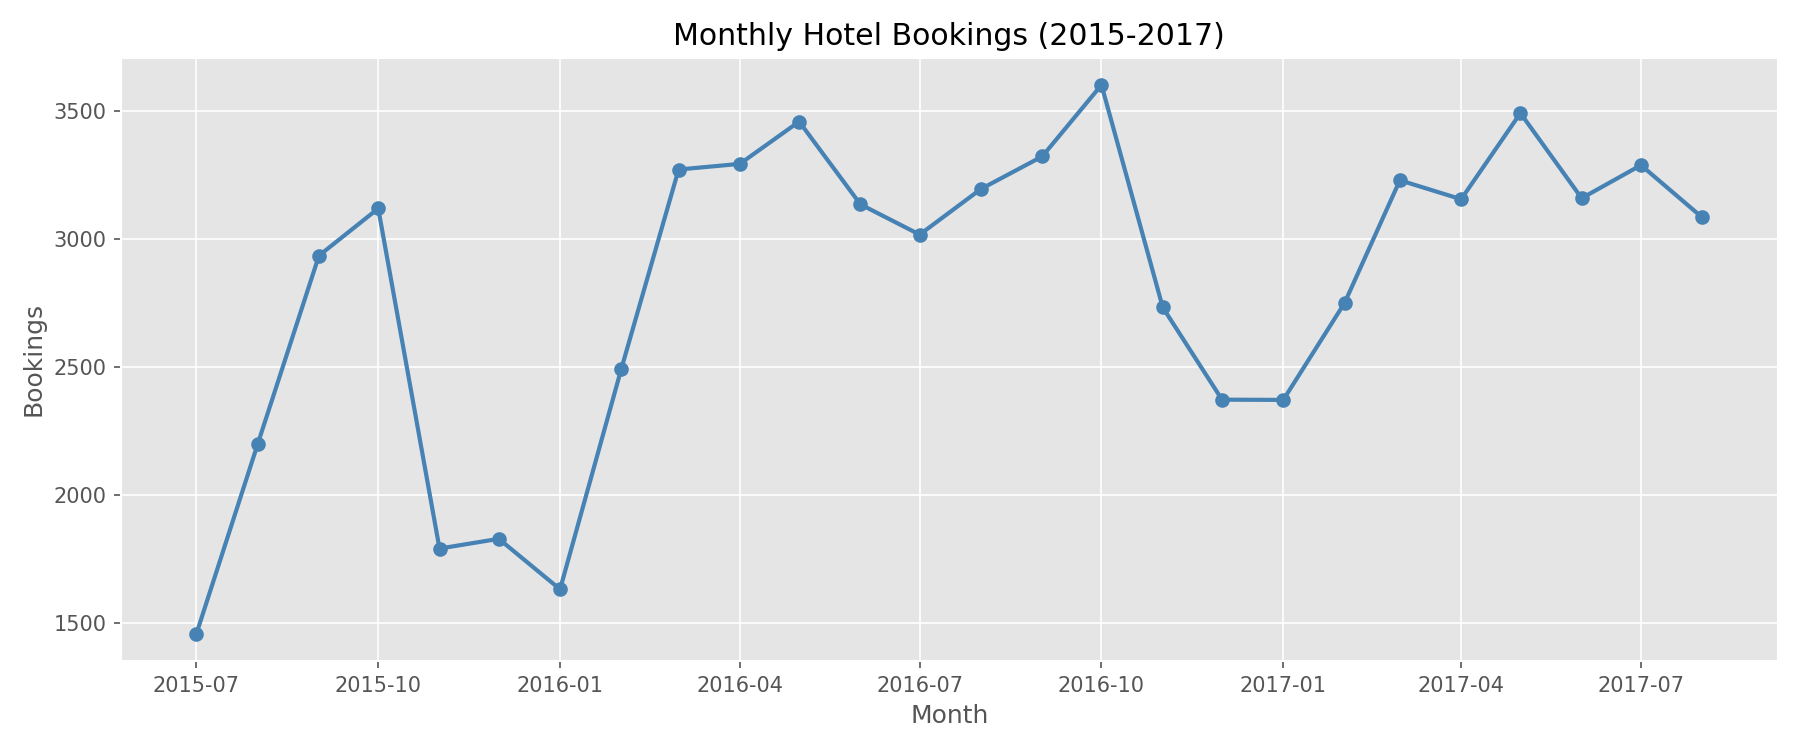

In [88]:
Image('plot_monthly_trend.png')

In [89]:
import os

In [90]:
print(os.getcwd())

C:\Users\hh


In [91]:
save_path = os.getcwd()

In [92]:
top_countries = df_clean['country'].value_counts().head(10)

In [93]:
fig, ax = plt.subplots(figsize=(10,4))

In [94]:
ax.bar(top_countries.index, top_countries.values, color='teal', edgecolor='black')

<BarContainer object of 10 artists>

In [95]:
ax.set_title('Top 10 Guest Countries')

Text(0.5, 1.0, 'Top 10 Guest Countries')

In [96]:
import os

In [97]:
save_path = os.getcwd()

In [98]:
top_countries = df_clean['country'].value_counts().head(10)

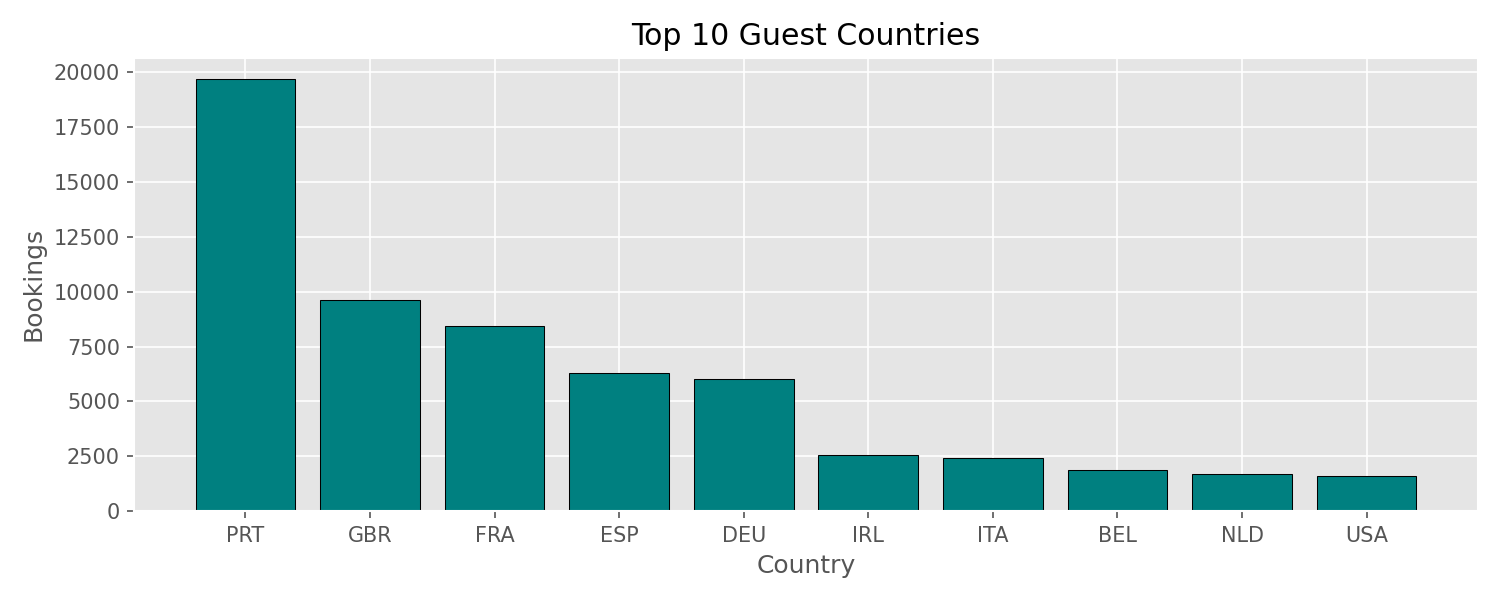

In [99]:
import os
save_path = os.getcwd()

top_countries = df_clean['country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10,4))
ax.bar(top_countries.index, top_countries.values, color='teal', edgecolor='black')
ax.set_title('Top 10 Guest Countries')
ax.set_xlabel('Country')
ax.set_ylabel('Bookings')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'plot_countries.png'), dpi=150)
plt.close()
from IPython.display import Image
Image(os.path.join(save_path, 'plot_countries.png'))

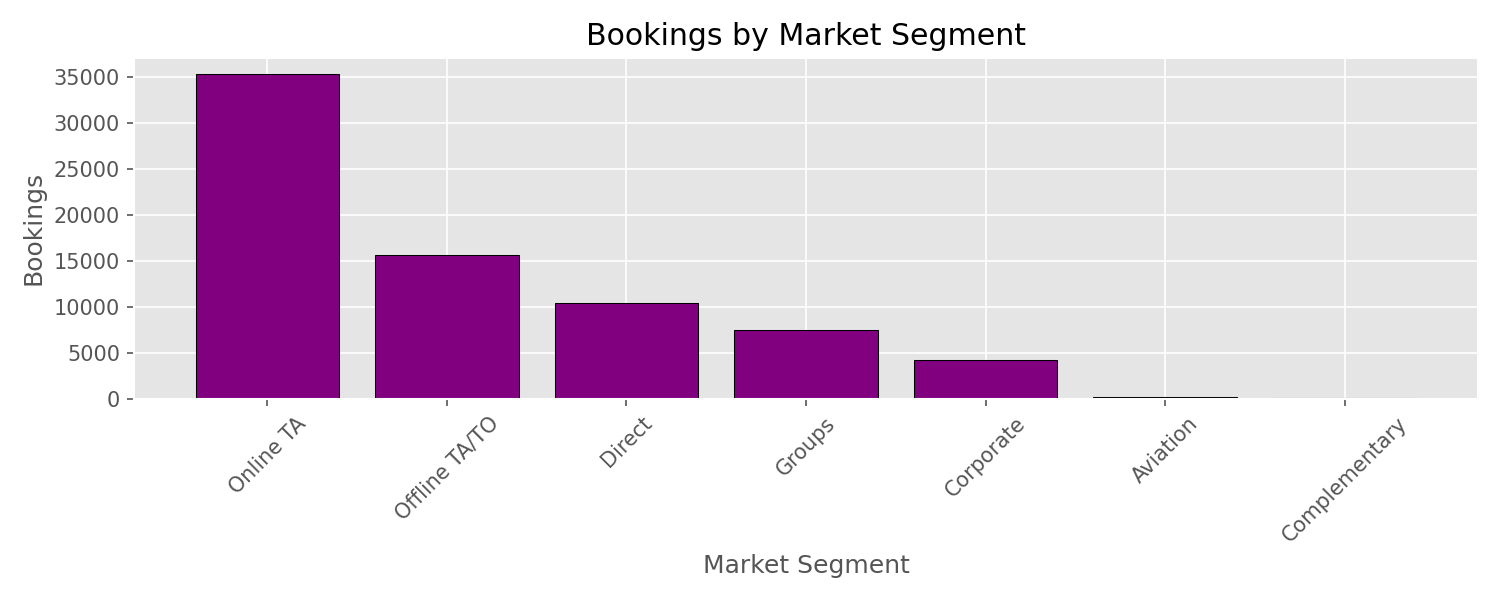

In [100]:
market_counts = df_clean['market_segment'].value_counts()

fig, ax = plt.subplots(figsize=(10,4))
ax.bar(market_counts.index, market_counts.values, color='purple', edgecolor='black')
ax.set_title('Bookings by Market Segment')
ax.set_xlabel('Market Segment')
ax.set_ylabel('Bookings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot_market.png', dpi=150)
plt.close()
Image('plot_market.png')

customer_type
Transient          51779
Transient-Party    18317
Contract            2791
Group                501
Name: count, dtype: int64


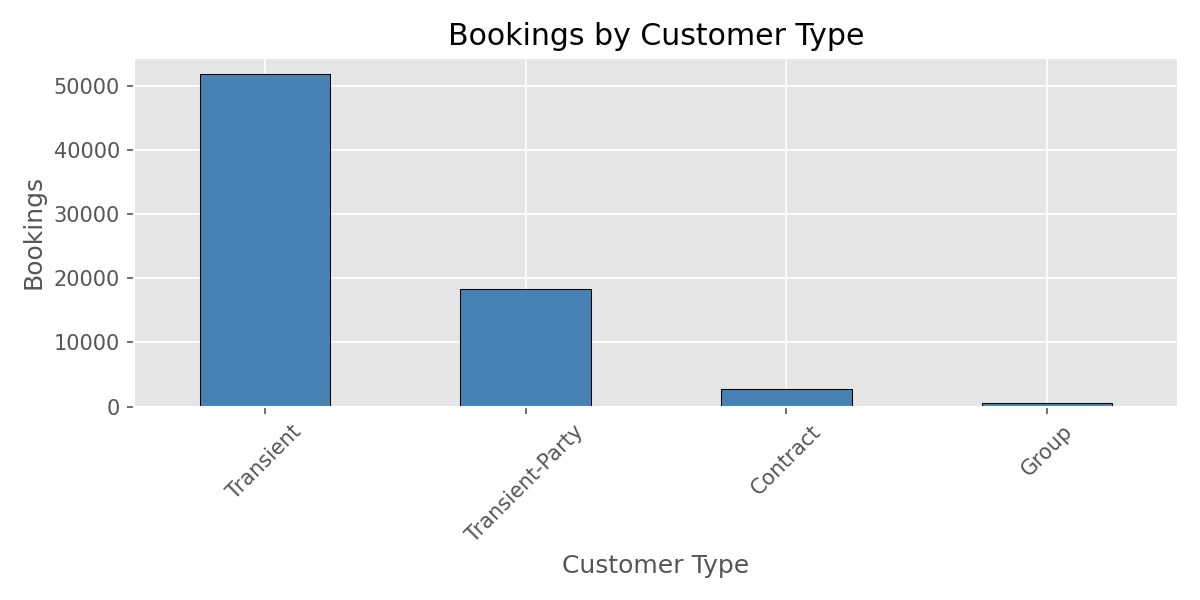

In [101]:
import os
save_path = os.getcwd()

customer_counts = df_clean['customer_type'].value_counts()
print(customer_counts)

fig, ax = plt.subplots(figsize=(8,4))
customer_counts.plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Bookings by Customer Type')
ax.set_xlabel('Customer Type')
ax.set_ylabel('Bookings')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'plot_customer_type.png'), dpi=150)
plt.close()
from IPython.display import Image
Image(os.path.join(save_path, 'plot_customer_type.png'))

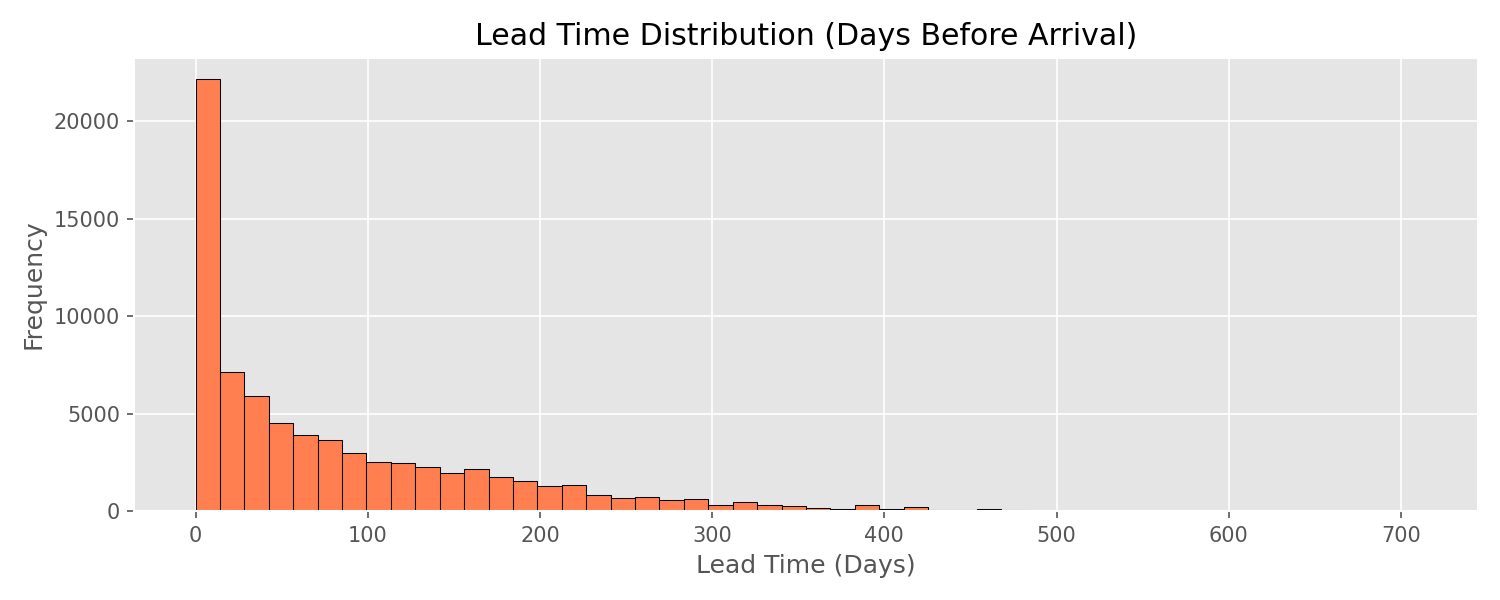

In [102]:
fig, ax = plt.subplots(figsize=(10,4))
ax.hist(df_clean['lead_time'], bins=50, color='coral', edgecolor='black')
ax.set_title('Lead Time Distribution (Days Before Arrival)')
ax.set_xlabel('Lead Time (Days)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'plot_lead_time.png'), dpi=150)
plt.close()
Image(os.path.join(save_path, 'plot_lead_time.png'))

In [103]:
monthly = df_clean.groupby('arrival_date').size().reset_index(name='bookings')
monthly = monthly.sort_values('arrival_date').set_index('arrival_date')

print("Monthly Time Series:")
print(monthly)
print(f"\nTotal months: {len(monthly)}")
print(f"Date range: {monthly.index.min()} to {monthly.index.max()}")

Monthly Time Series:
              bookings
arrival_date          
2015-07-01        1460
2015-08-01        2200
2015-09-01        2935
2015-10-01        3119
2015-11-01        1792
2015-12-01        1830
2016-01-01        1633
2016-02-01        2493
2016-03-01        3271
2016-04-01        3293
2016-05-01        3458
2016-06-01        3135
2016-07-01        3017
2016-08-01        3195
2016-09-01        3322
2016-10-01        3601
2016-11-01        2733
2016-12-01        2373
2017-01-01        2372
2017-02-01        2750
2017-03-01        3229
2017-04-01        3155
2017-05-01        3491
2017-06-01        3159
2017-07-01        3288
2017-08-01        3084

Total months: 26
Date range: 2015-07-01 00:00:00 to 2017-08-01 00:00:00


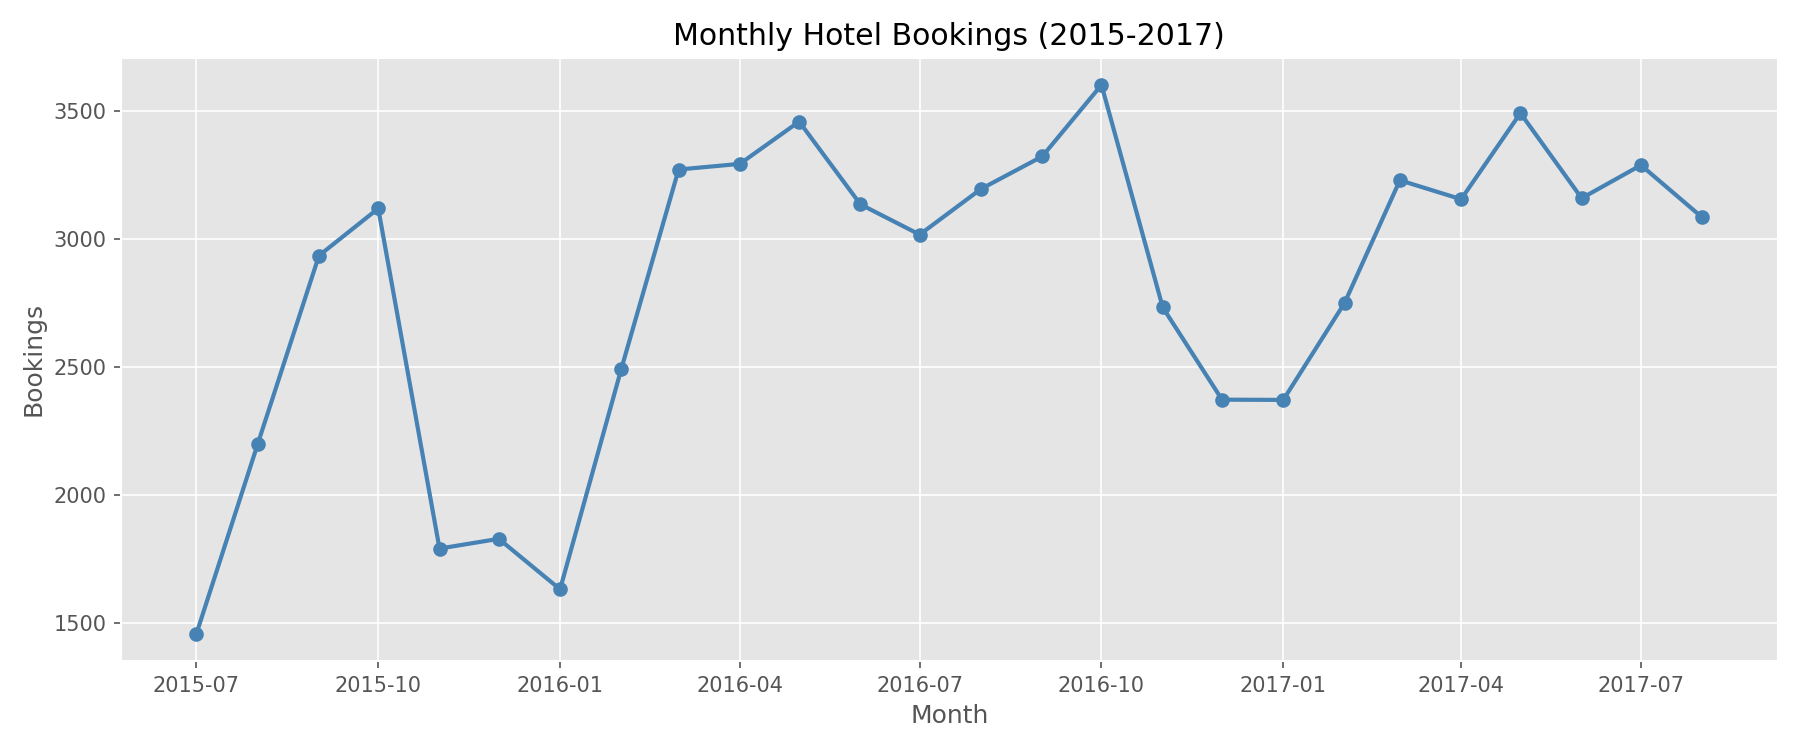

In [104]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(monthly.index, monthly['bookings'], marker='o', color='steelblue', linewidth=2)
ax.set_title('Monthly Hotel Bookings (2015-2017)')
ax.set_xlabel('Month')
ax.set_ylabel('Bookings')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'plot_timeseries.png'), dpi=150)
plt.close()
from IPython.display import Image
Image(os.path.join(save_path, 'plot_timeseries.png'))

In [105]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly['bookings'])
print('ADF Stationarity Test')
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')
print()
if result[1] < 0.05:
    print('✅ Series is STATIONARY (p < 0.05)')
else:
    print('❌ Series is NON-STATIONARY (p > 0.05)')
    print('We need to difference the series for ARIMA')

ADF Stationarity Test
ADF Statistic : -2.2964
p-value       : 0.1731

❌ Series is NON-STATIONARY (p > 0.05)
We need to difference the series for ARIMA


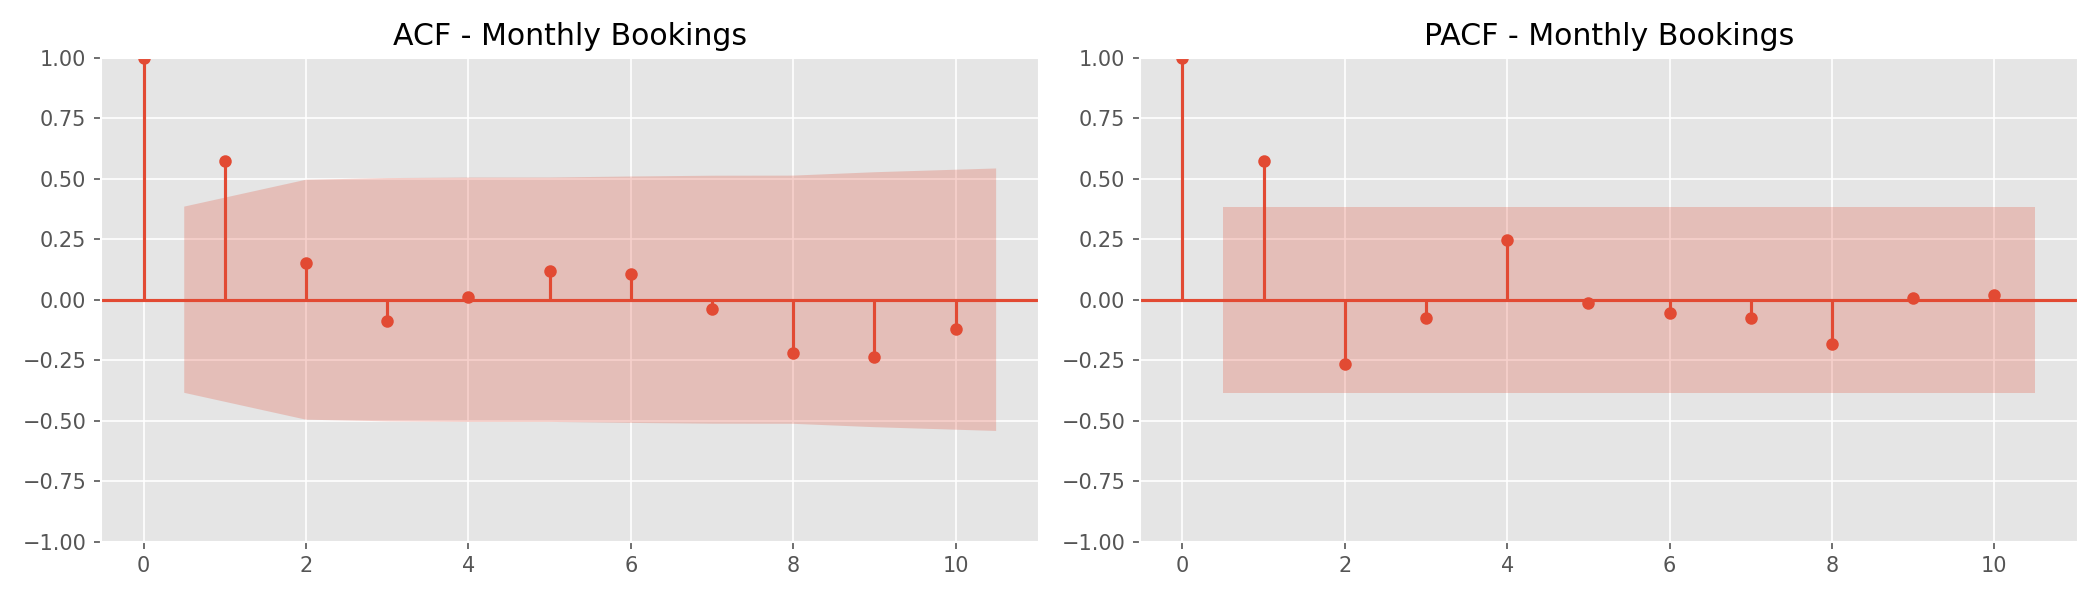

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(monthly['bookings'], lags=10, ax=axes[0], title='ACF - Monthly Bookings')
plot_pacf(monthly['bookings'], lags=10, ax=axes[1], title='PACF - Monthly Bookings')
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'plot_acf_pacf.png'), dpi=150)
plt.close()
from IPython.display import Image
Image(os.path.join(save_path, 'plot_acf_pacf.png'))

In [107]:
train = monthly[:-6]
test = monthly[-6:]

print(f"Train: {len(train)} months")
print(f"Test : {len(test)} months")
print(f"\nTrain period: {train.index[0].strftime('%Y-%m')} to {train.index[-1].strftime('%Y-%m')}")
print(f"Test period : {test.index[0].strftime('%Y-%m')} to {test.index[-1].strftime('%Y-%m')}")

Train: 20 months
Test : 6 months

Train period: 2015-07 to 2017-02
Test period : 2017-03 to 2017-08


In [108]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train['bookings'], order=(1,1,1))
arima_fit = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               bookings   No. Observations:                   20
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -146.300
Date:                Mon, 06 Apr 2026   AIC                            298.601
Time:                        07:49:58   BIC                            301.434
Sample:                    07-01-2015   HQIC                           299.080
                         - 02-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7819      0.493      1.586      0.113      -0.184       1.748
ma.L1         -0.9137      0.435     -2.102      0.036      -1.766      -0.062
sigma2      2.775e+05   1.22e+05      2.277      0.0

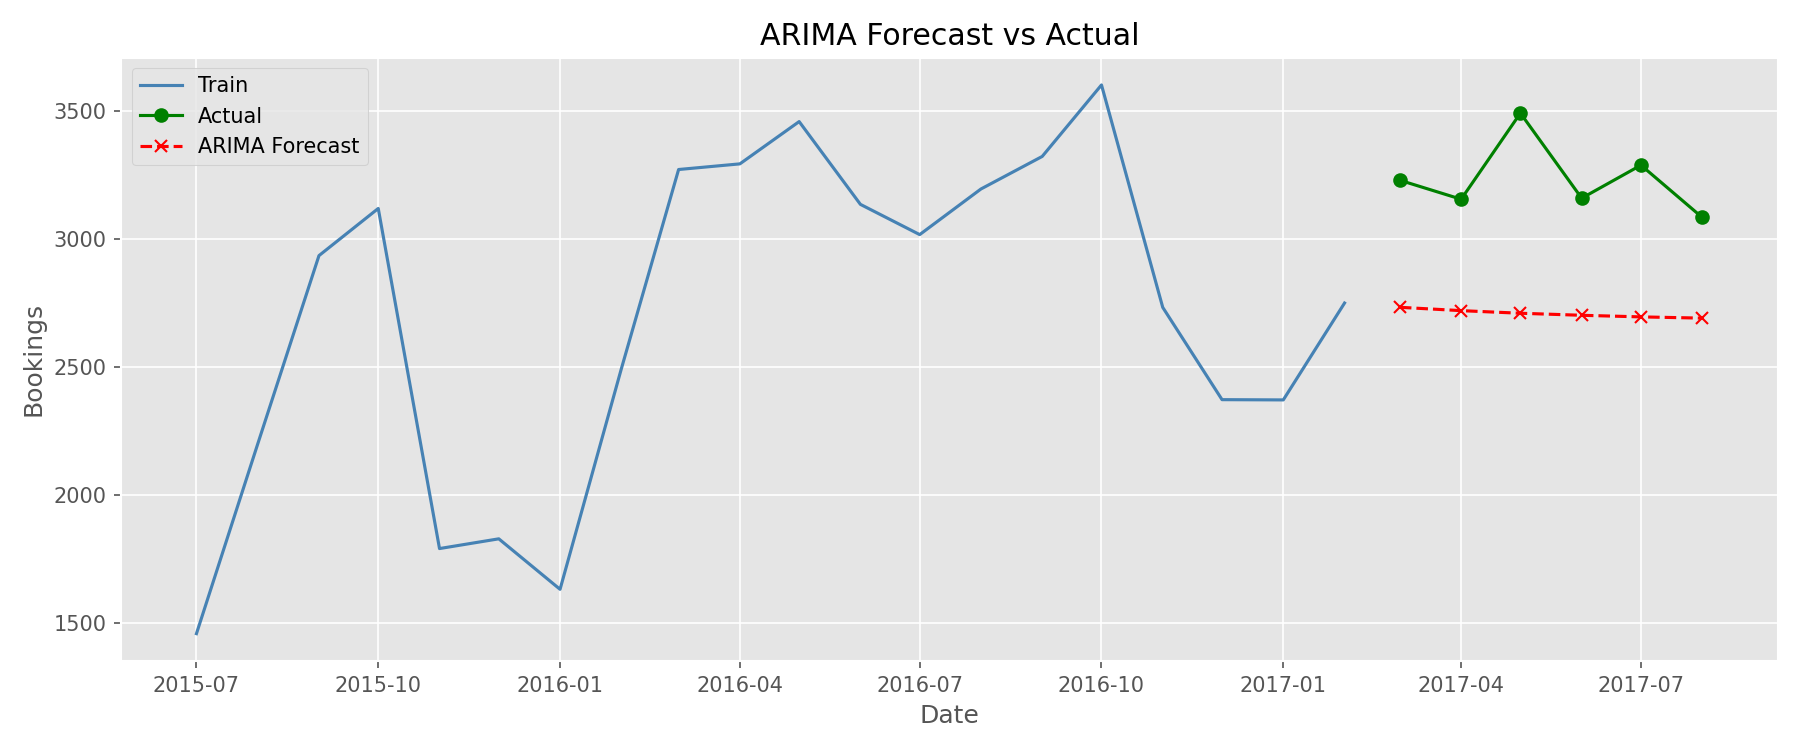

In [109]:
arima_forecast = arima_fit.forecast(steps=6)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train.index, train['bookings'], label='Train', color='steelblue')
ax.plot(test.index, test['bookings'], label='Actual', color='green', marker='o')
ax.plot(test.index, arima_forecast, label='ARIMA Forecast', color='red', linestyle='--', marker='x')
ax.set_title('ARIMA Forecast vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Bookings')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'plot_arima.png'), dpi=150)
plt.close()
from IPython.display import Image
Image(os.path.join(save_path, 'plot_arima.png'))

In [110]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(train['bookings'], 
                       order=(1,1,1), 
                       seasonal_order=(1,1,1,12))
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                           bookings   No. Observations:                   20
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -50.894
Date:                            Mon, 06 Apr 2026   AIC                            111.787
Time:                                    07:50:01   BIC                            111.517
Sample:                                07-01-2015   HQIC                           108.444
                                     - 02-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7820     10.075      0.078      0.938     -18.964      20.528
ma.L1         -0.7273      9.829   

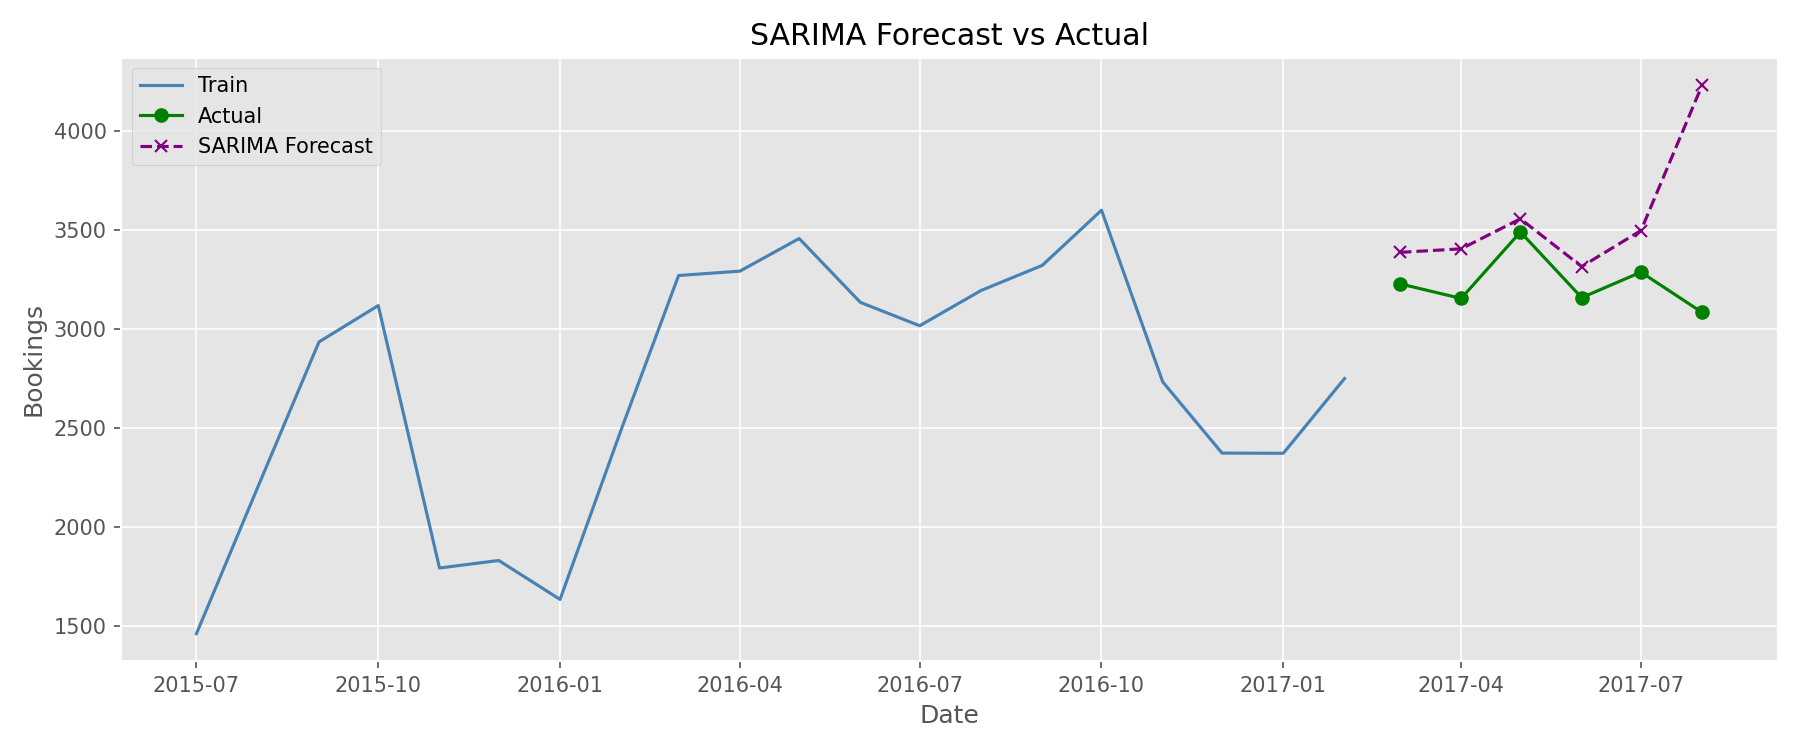

In [111]:
sarima_forecast = sarima_fit.forecast(steps=6)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(train.index, train['bookings'], label='Train', color='steelblue')
ax.plot(test.index, test['bookings'], label='Actual', color='green', marker='o')
ax.plot(test.index, sarima_forecast, label='SARIMA Forecast', color='purple', linestyle='--', marker='x')
ax.set_title('SARIMA Forecast vs Actual')
ax.set_xlabel('Date')
ax.set_ylabel('Bookings')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(save_path, 'plot_sarima.png'), dpi=150)
plt.close()
from IPython.display import Image
Image(os.path.join(save_path, 'plot_sarima.png'))

In [112]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(actual, predicted, model_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f'--- {model_name} ---')
    print(f'  MAE  : {mae:.2f}')
    print(f'  RMSE : {rmse:.2f}')
    print(f'  MAPE : {mape:.2f}%')
    print()
    return {'Model': model_name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE(%)': round(mape,2)}

r1 = evaluate_model(test['bookings'], arima_forecast, 'ARIMA(1,1,1)')
r2 = evaluate_model(test['bookings'], sarima_forecast, 'SARIMA(1,1,1)(1,1,1,12)')

results_df = pd.DataFrame([r1, r2])
print('Model Comparison:')
print(results_df)

--- ARIMA(1,1,1) ---
  MAE  : 525.48
  RMSE : 541.27
  MAPE : 16.12%

--- SARIMA(1,1,1)(1,1,1,12) ---
  MAE  : 332.47
  RMSE : 497.60
  MAPE : 10.58%

Model Comparison:
                     Model     MAE    RMSE  MAPE(%)
0             ARIMA(1,1,1)  525.48  541.27    16.12
1  SARIMA(1,1,1)(1,1,1,12)  332.47  497.60    10.58


In [113]:
results_df.to_csv(os.path.join(save_path, 'model_results.csv'), index=False)
print("✅ Results saved!")
print("\nFinal Conclusion:")
print("Best Model : SARIMA(1,1,1)(1,1,1,12)")
print("MAE        : 332.47")
print("RMSE       : 497.60")
print("MAPE       : 10.58%")
print("\nSARIMA captures seasonal patterns better than ARIMA")
print("for hotel booking demand forecasting.")

✅ Results saved!

Final Conclusion:
Best Model : SARIMA(1,1,1)(1,1,1,12)
MAE        : 332.47
RMSE       : 497.60
MAPE       : 10.58%

SARIMA captures seasonal patterns better than ARIMA
for hotel booking demand forecasting.
